## PatchTST - A Transformer Architecture for long-term forecasting for time-series - Training auf dem Electricity Datensatz Etth1

Wir gehen in diesem Notebook nicht auf die Details von PatchTST ein, sondern konzentrieren uns auf das Training und die Interpretation der Ergebnisse. 

Die Reihenfolge orientiert sich am **CRISP-DM-Modell**:

1. Geschäftsverständnis
2. Datenverständnis
3. Datenvorbereitung
4. Modeling
5. Evaluation
6. Deployment

Wichtig: CRISP-DM ist kein einmaliger Durchlauf. Feedback aus der Evaluation oder aus dem Fachbereich kann dazu führen, dass wir eine weitere Iteration starten und Annahmen, Daten oder Modellierung anpassen.

## PatchTST - Modell Architektur und Erläuterung der einzelnen Schichten


In [1]:
# Import von Tensorflow
import tensorflow as tf
tf.config.run_functions_eagerly(True)
from tensorflow.keras import layers

In [2]:
import numpy as np
np.random.seed(42) # Wiederholbare Ergebnisse erzeugen.

Die Embedding Schicht unseres Modells:

Striktes Channel-Independence - dies unterscheidet unser Modell zu den Vorgängern.

In [3]:
class PatchTSTEmbedding(layers.Layer):
    def __init__(self, patch_len, stride, d_model):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        self.proj = layers.Dense(d_model)

    def call(self, x):
        # x Form: (batch, seq_len, channels)
        batch = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]
        channels = tf.shape(x)[2]

        # 1. Striktes Channel-Independence: Kanäle in die Batch-Dimension verschieben
        # Neuen Form: (batch, channels, seq_len)
        x = tf.transpose(x, perm=[0, 2, 1])
        # Zusammenfassen zu: (batch * channels, seq_len)
        x = tf.reshape(x, (batch * channels, seq_len))

        # 2. Extraktion der Patches mit Stride (Überlappung) mithilfe von Slicing oder tf.signal
        # (Zur Vereinfachung hier via Slicing für überlappende Fenster)
        num_patches = (seq_len - self.patch_len) // self.stride + 1
        
        patches = []
        for i in range(num_patches):
            start = i * self.stride
            end = start + self.patch_len
            patches.append(x[:, start:end])
        
        # Form nach Stack: (num_patches, batch * channels, patch_len)
        x = tf.stack(patches, axis=0)
        # Umformen zu: (batch * channels, num_patches, patch_len)
        x = tf.transpose(x, perm=[1, 0, 2])

        # 3. Lineare Projektion auf die Transformer-Dimension d_model
        # Jedes univariate Patch wird jetzt projiziert
        return self.proj(x)  # Ausgabeform: (batch * channels, num_patche

Die Positional Encoding Schicht stellt sicher, dass die Eigenschaften der Zeitreihe und erhalten bleiben.

In [4]:
class PatchTSTPositionalEncoding(layers.Layer):
    def __init__(self, num_patches, d_model):
        super().__init__()
        # Lernbare Gewichte für die Positionen: (Num_Patches, d_model)
        self.pos_embed = self.add_weight(
            name="pos_embed",
            shape=(num_patches, d_model),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True
        )

    def call(self, x):
        # x Form: (Batch * Channels, Num_Patches, d_model)
        # Dank Broadcasting wird das (Num_Patches, d_model) Embedding 
        # automatisch auf alle (Batch * Channels) addiert.
        return x + self.pos_embed

Die TransformerSchicht unseres Modells besteht aus den folgenden Schichten:

1. Multi-Head Attention (MHA)Funktion: Berechnet die Beziehungen (Attention) der Patches untereinander innerhalb eines einzelnen Kanals.Besonderheit: Da PatchTST jeden Kanal als eigenen Batch behandelt (Channel Independence), sieht die Attention-Schicht keine Korrelationen zwischen verschiedenen Kanälen. Sie fokussiert sich rein auf die zeitliche Struktur (Semantik) innerhalb der Patches einer Zeitreihe.

2. Layer Normalization & Residual ConnectionsAufbau: Wie im klassischen Transformer (oft als Pre-LN implementiert) wird vor der Attention-Schicht eine Layer Normalization angewendet.
Residuals: Das ursprüngliche Patch-Signal wird per Shortcut-Verbindung (Add) nach der Attention wieder hinzugerechnet, um den Gradientenfluss in tiefen Netzen stabil zu halten.

3. Feed-Forward Network (FFN / MLP)Aufbau: Besteht aus zwei linearen Schichten mit einer nicht-linearen Aktivierungsfunktion GELU dazwischen.

Dimensionen: Projiziert die Vektoren der Patches von der Modell-Dimension (d_model=128) hoch in eine tiefere Repräsentationsdimension (mlp_dim=256) und spiegelt sie anschließend wieder auf d_model zurück.

4. Zweite Layer Normalization & Residual Connection: Schließt den Layer ab, normiert die Ausgaben des Feed-Forward-Netzwerks und addiert das Signal vor dem FFN-Block, bevor die Daten an den nächsten Transformer-Layer (oder den Forecasting-Head) weitergereicht werden.

In [5]:
class PatchTSTTransformerBlock(layers.Layer):
    def __init__(self, d_model, n_heads, dimPT, dropout=0.1):
        super().__init__()
        # Multi-Head Attention Komponente
        self.mha = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model // n_heads)
        
        # Position-wise Feed-Forward Network (FFN) mit GELU
        self.ffn = tf.keras.Sequential([
            layers.Dense(dimPT, activation='gelu'),
            layers.Dropout(dropout),
            layers.Dense(d_model)
        ])
        
        # Layer Normalization (Pre-LN Struktur)
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-5)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-5)
        
        # Dropout für die Residuen-Verbindungen
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        # x Form: (Batch * Channels, Num_Patches, d_model)
        
        # 1. Erster Block: Pre-LN -> Attention -> Dropout -> Residual-Addition
        norm_x1 = self.layernorm1(x)
        attn_output = self.mha(query=norm_x1, value=norm_x1, key=norm_x1, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        x = x + attn_output
        
        # 2. Zweiter Block: Pre-LN -> FFN -> Dropout -> Residual-Addition
        norm_x2 = self.layernorm2(x)
        ffn_output = self.ffn(norm_x2, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        x = x + ffn_output
        
        return x  # Ausgabe-Form bleibt: (Batch * Channels, Num_Patches, d_model)


Die Flatten Head Schicht, ist für die Vorhersagen unseres Prediction Modells verantwortlich

In [6]:
class PatchTSTFlattenHead(layers.Layer):
    def __init__(self, num_patches, d_model, pred_len):
        super().__init__()
        self.pred_len = pred_len
        
        # Lineare Schicht zur Vorhersage der zukünftigen Werte
        # Input-Größe implizit: num_patches * d_model
        self.flatten = layers.Flatten()
        self.linear = layers.Dense(pred_len)

    def call(self, x, batch_size, num_channels):
        # x Form beim Eingang: (Batch * Channels, Num_Patches, d_model)
        
        # 1. Abflachen: (Batch * Channels, Num_Patches * d_model)
        x = self.flatten(x)
        
        # 2. Lineare Projektion auf den Vorhersage-Horizont: (Batch * Channels, pred_len)
        x = self.linear(x)
        
        # 3. Zurückfalten in die originale Kanal-Struktur:
        # Erst trennen: (Batch, Channels, pred_len)
        x = tf.reshape(x, (batch_size, num_channels, self.pred_len))
        
        # Dimensionen zurücktauschen zu: (Batch, pred_len, Channels)
        x = tf.transpose(x, perm=[0, 2, 1])
        
        return x

### Das finale PatchTSTSelfSupervised Modell

Aufbau:
- PatchTSTEmbedding Schicht
- PatchTSTPositionalEncoding Schicht
- PatchTSTTransformer Schichten
- Fully Connected Layer Schicht

Die Fully Connected Layer Schicht unterscheidet das PatchTSTSElfSupervised Modell vom PatchTST Vorhersagemodell, welches weiter unten erstellt wird.


In [7]:
#Selfsupervised PatchTST erstellen und Schichten zusammenbauen
class PatchTSTSelfSuper(tf.keras.Model):

    def __init__(
            self,
            seq_len,
            patch_len,
            stride,
            d_model,
            depth,
            heads,
            mlp_dim,
            num_channels):

        super().__init__()

        self.patch_len = patch_len
        self.channels = num_channels

         # Berechnen der exakten Patch-Anzahl vorab
        self.num_patches = (seq_len - patch_len) // stride + 1

        self.patch_embed = PatchTSTEmbedding(
            patch_len,
            stride,
            d_model
        )

        self.position = PatchTSTPositionalEncoding(num_patches=self.num_patches, d_model=d_model)
        

        self.encoder = [
            PatchTSTTransformerBlock(
                d_model,
                heads, 
                mlp_dim
                )
                for _ in range(depth)
                ]
    

        # Reconstruction Head
        self.head = layers.Dense(
            patch_len * num_channels
        )

    def call(self, x):
        #if training is None:
        #   training = False

        x = self.patch_embed(x)

        x = self.position(x)

        for block in self.encoder:
            x=block(x)
            #x = block(x, training)

        x = self.head(x)

        return x


### Das finale PatchTST Vorhersage Modell

Aufbau:
- PatchTSTEmbedding Schicht
- PatchTSTPositionalEncoding Schicht
- PatchTSTTransformer Schichten
- Flatten Head Schicht

Kurz notiert, das PatchTST Vorhersagemodell hat eine Flatten Head Schicht um Vorhersagen treffen zu können.

In [8]:
class PatchTSTModel(tf.keras.Model):
    def __init__(self, seq_len, patch_len, stride, d_model, heads, mlp_dim, depth, num_channels, pred_len):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        
        # Berechnen der exakten Patch-Anzahl vorab
        self.num_patches = (seq_len - patch_len) // stride + 1
        
        # Schichten initialisieren
        self.embedding = PatchTSTEmbedding(patch_len=patch_len, stride=stride, d_model=d_model)
        self.pos_encoding = PatchTSTPositionalEncoding(num_patches=self.num_patches, d_model=d_model)
        
        self.encoder_layers = [
            PatchTSTTransformerBlock(d_model, heads, mlp_dim) 
            for _ in range(depth)
        ]
        
        self.head = PatchTSTFlattenHead(num_patches=self.num_patches, d_model=d_model, pred_len=pred_len)

    def call(self, inputs, training=False):
        # inputs Form: (Batch, seq_len, Channels)
        batch_size = tf.shape(inputs)[0]
        num_channels = tf.shape(inputs)[2]
        
        # 1. Patching & Embedding -> (Batch * Channels, Num_Patches, d_model)
        x = self.embedding(inputs)
        
        # 2. Positional Encoding addieren
        x = self.pos_encoding(x)
        
        # 3. Durch die Transformer-Blöcke schleifen
        for transformer_block in self.encoder_layers:
            x = transformer_block(x, training=training)
            
        # 4. Flatten-Head: Zurückrechnen auf die Ziel-Kanäle -> (Batch, pred_len, Channels)
        outputs = self.head(x, batch_size=batch_size, num_channels=num_channels)
        
        return outputs

### Use Case aus dem OriginalPaper nachstellen und das PatchTST Vorhersage Modell nutzen

In [ ]:
#Testen
# Modell erstellen

seq_len = 512 
channels = 3


model = PatchTSTModel(
    seq_len=seq_len,
    patch_len=16,
    stride=128,
    d_model=128,
    heads=8,
    mlp_dim=256,
    depth=6, 
    num_channels=3,
    pred_len=512
)

dummy = tf.random.normal(shape=(8, seq_len, 3),dtype=float)

#Prüfen, welche Größe das PatchTST Modell im Ausgabelayer hat:
out = model(dummy)
print(out.shape)




#







(8, 512, 3)


### Das Vorhersage-Modell PatchTST auf den ETTH1 Datensatz angewendet.


Wir trainieren das PatchTST-Prediction-Modell auf dem  ETTh1-Datensatz, Electricity Transformer Dataset Hourly 1. Dieser Datensatz wurde unter anderem auch von den Autoren von PatchTST in ihrem Paper verwendet. Laut unserer Recherche ist der Datensatz einer der weltweit bekanntesten Standard-Datensätze im Bereich der Künstlichen Intelligenz (KI) um Zeitreihenprognosen zu testen.


Der Datensatz enthält Messdaten von Stromtransformatoren, mit denen Forscher ihren KI-Modellen beibringen, die zukünftige Strombelastung vorherzusagen

Jede Zeile enthält das genaue Datum mit Uhrzeit sowie 7 Features:

HUFL (High Use Full Load): Die Belastung im Zustand hoher Auslastung.

HULL (High Use Light Load): Die Belastung im Zustand geringer Auslastung bei hoher Nutzung.

MUFL (Medium Use Full Load): Mittlere Auslastung unter Volllast.

MULL (Medium Use Light Load): Mittlere Auslastung unter Leichtlast.

LUFL (Low Use Full Load): Niedrige Auslastung unter Volllast.

LULL (Low Use Light Load): Niedrige Auslastung unter Leichtlast.

OT (Oil Temperature): Die Öltemperatur des Strom-Transformators



Schritt 1: Hyperparameter definieren

In [11]:
import warnings

BATCH_SIZE = 16
SEQ_LEN = 512      # Historische Schauzeit (Lookback-Window)
CHANNELS = 7       # Anzahl paralleler Features/Variablen (z.B. Wetterdaten)
PRED_LEN = 96      # Vorhersagehorizont (Zukunft)

PATCH_LEN = 16     # Länge eines einzelnen Patches
STRIDE = 8         # Schrittweite (50% Überlappung)
D_MODEL = 128      # Transformer Embedding-Dimension
N_HEADS = 16        # Multi-Head Attention Köpfe
D_FF = 256         # Feed-Forward Dimension im Transformer
NUM_LAYERS = 3     # Anzahl der Transformer-Blöcke 

Schritt 2: Orginale Daten laden und skalieren

In [12]:
from pathlib import Path
import pandas as pd
dateiname = "ETTh1.csv"

DATASET_BASE_DIR = Path(r"dataset")
print(DATASET_BASE_DIR)

dataset


In [13]:
import pandas as pd

# 1. Load the CSV file into a DataFrame
df = pd.read_csv('dataset/ETTh1.csv')
print("Datei gefunden.")

# 2. Extract columns directly into lists using .tolist()
# (Replace 'Column_Name_X' with your actual CSV header names)
col1 = df['date'].tolist()
col2 = df['HUFL'].tolist()
col3 = df['HULL'].tolist()
col4 = df['MUFL'].tolist()
col5 = df['MULL'].tolist()
col6 = df['LUFL'].tolist()
col7 = df['LULL'].tolist()
col8 = df['OT'].tolist()


Datei gefunden.


In [14]:
import numpy as np
# Erste Spalte ignorieren, da diese die Zeitschritte enthält.

# Datenumwandeln in ein Numpy Array damit unser Modell damit arbeiten kann.
etth1_data = np.stack([col2, col3, col4, col5, col6, col7, col8], axis=-1).astype(np.float32)
print("--- CSV DATEN GELADEN ---")
print(f"Form des ursprünglichen Arrays: {etth1_data.shape} -> (Zeitschritte, 7 Kanäle)")

--- CSV DATEN GELADEN ---
Form des ursprünglichen Arrays: (17420, 7) -> (Zeitschritte, 7 Kanäle)


In [15]:
# Den Index für die Trennung berechnen (erste 80%)
split_idx = int(len(etth1_data) * 0.8)

# Daten in zwei separate Zeitreihen-Blöcke schneiden
etth1_train_raw = etth1_data[:split_idx]
etth1_test_raw = etth1_data[split_idx:]

print(f"Zeilen für Training:       {len(etth1_train_raw)}")
print(f"Zeilen für Test/Validierung: {len(etth1_test_raw)}\n")

Zeilen für Training:       13936
Zeilen für Test/Validierung: 3484



In [16]:
#Skalierung der Trainingsdaten

# Mittelwert & Std NUR vom Training berechnen!
means = np.mean(etth1_train_raw, axis=0)
stds = np.std(etth1_train_raw, axis=0)
stds = np.where(stds == 0, 1.0, stds)

# BEIDE Blöcke mit den identischen Train-Parametern skalieren
etth1_train_scaled = (etth1_train_raw - means) / stds
etth1_test_scaled = (etth1_test_raw - means) / stds

print("Daten skaliert")

Daten skaliert


Schritt 3: Batch- Aufteilung (Vorhersage Windows erstellen) nachdem die Daten skaliert sind

In [17]:
SEQ_LEN = 512
PRED_LEN = 96
STEP_SIZE = 16 # Schrittweite für die Fenster-Verschiebung

def create_windows(data_sequence):
    X, Y = [], []
    # Loop läuft so lange, wie ein volles Fenster (History + Zukunft) hineinpasst
    for i in range(0, len(data_sequence) - SEQ_LEN - PRED_LEN, STEP_SIZE):
        X.append(data_sequence[i : i + SEQ_LEN])
        Y.append(data_sequence[i + SEQ_LEN : i + SEQ_LEN + PRED_LEN])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

# Fenster für beide Datensätze unabhängig generieren
X_train, Y_train = create_windows(etth1_train_scaled)
X_val, Y_val = create_windows(etth1_test_scaled)

print("--- FINALE PATCHTST DIMENSIONEN ---")
print(f"X_train (Train Inputs):  {X_train.shape} -> (Batches, {SEQ_LEN}, 7)")
print(f"Y_train (Train Targets): {Y_train.shape} -> (Batches, {PRED_LEN}, 7)")
print(f"X_val   (Test Inputs):   {X_val.shape}")

--- FINALE PATCHTST DIMENSIONEN ---
X_train (Train Inputs):  (833, 512, 7) -> (Batches, 512, 7)
Y_train (Train Targets): (833, 96, 7) -> (Batches, 96, 7)
X_val   (Test Inputs):   (180, 512, 7)


Schritt 4: Vorhersage-PatchTST-Modell instanziieren und testen

In [19]:
# Instanziierung des zuvor definierten Gesamtmodells
model = PatchTSTModel(
    seq_len=SEQ_LEN,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    d_model=D_MODEL,
    heads=N_HEADS,
    mlp_dim=D_FF,
    depth=NUM_LAYERS,
    num_channels=CHANNELS,
    pred_len=PRED_LEN
)

# Test-Vorhersage ohne Training (Forward Pass)
predictions = model(X_train, training=False)

print("--- Dimension des Ausgabelayers prüfen: ---")
print(f"Dimension des Ausgabenlayer:     {predictions.shape} -> Sollte exakt Y_train entsprechen!\n")


NameError: name 'PatchTSTModel' is not defined

Schritt 5: MODELL wird Kompiliert und nutzt hierbei den Optimizer ADAM und die Lossfunktion MSE

In [ ]:
# 4. MODELL wird Kompiliert und nutzt hierbei den Optimizer ADAM und die Lossfunktion MSE
# =====================================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae']
)
# 5. Kurzes Probetraining mit 7 Durchläufen
# =====================================================================
warnings.filterwarnings("ignore")
print("--- TRAINING über 100 Durchläufe---")
#Kurzer Test-Lauf, um zu sehen, ob Backpropagation fehlerfrei läuft
history = model.fit(X_train, Y_train, epochs=100, batch_size=BATCH_SIZE, verbose=1)
print("\n✔ Modell Test erfolgreich, Dimensionen des Modells passen.")

--- TRAINING über 100 Durchläufe---
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 583ms/step - loss: 2.3351 - mae: 1.1851
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 580ms/step - loss: 1.3148 - mae: 0.8988
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 578ms/step - loss: 1.0292 - mae: 0.7904
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 579ms/step - loss: 0.8622 - mae: 0.7200
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 578ms/step - loss: 0.7655 - mae: 0.6756
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 585ms/step - loss: 0.6976 - mae: 0.6414
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 579ms/step - loss: 0.6308 - mae: 0.6064
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 577ms/step - loss: 0.5869 - mae: 0.5826
Epoch 9/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 578ms/step - loss: 0.5613 - mae: 0.5691
Epoch 10/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 591ms/step - loss: 0.5348 - mae: 0.5530
Epoch 11/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 594ms/step - loss: 0.5082 - mae: 0.5377
Epoch 12/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 606ms

Schritt 6: (optional) Modell lokal speichern

In [ ]:
#model.save("patchtstPredModel_complete_model_Etth1.keras")
#print("Modell erfolgreich gespeichert!")

Schritt 7: Vorhersage-Methode und Vorhersage ausführen.

In [ ]:
def predict_supervised_forecasting(model, x_data):
    """
    Führt die Zukunftsvorhersage (Forecasting) für Supervised PatchTST aus.
    Schaltet den Trainingsmodus aus und liefert die finalen Vorhersagen.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # 1. Daten in Tensor umwandeln
        x_tensor = tf.convert_to_tensor(x_data, dtype=tf.float32)
        
        # 2. Forward Pass im Evaluations-Modus (training=False)
        # Das Supervised-Modell liefert hier die Vorhersage für die Zukunft
        predictions = model(x_tensor, training=False)
        
        # Falls das Modell ein komplexes Ausgabe-Objekt liefert (z.B. bei HuggingFace Modellen),
        # extrahieren wir die reinen Vorhersage-Tensoren:
        if hasattr(predictions, 'prediction_outputs'):
            predictions = predictions.prediction_outputs
        elif hasattr(predictions, 'logits'):
            predictions = predictions.logits
            
        return np.array(predictions, dtype=np.float32)

# --- VORHERSAGE AUSFÜHREN ---
# Wir übergeben die historischen Testdaten (X_val)
predictions_forecast = predict_supervised_forecasting(model, X_val)

# --- DIMENSIONEN VERGLEICHEN ---
print("--- FORECASTING-Dimensionen prüfen ---")
print(f"Eingabe (Historie) X_val:  {X_val.shape}  -> (Batch, Seq_Len, Channels)")
print(f"Modell-Vorhersage:          {predictions_forecast.shape}  -> Sollte (Batch, Pred_Len, Channels) sein")
print(f"Echte Zukunft Y_val:        {Y_val.shape}  -> (Batch, Pred_Len, Channels)")


--- FORECASTING-Dimensionen prüfen ---
Eingabe (Historie) X_val:  (180, 512, 7)  -> (Batch, Seq_Len, Channels)
Modell-Vorhersage:          (180, 96, 7)  -> Sollte (Batch, Pred_Len, Channels) sein
Echte Zukunft Y_val:        (180, 96, 7)  -> (Batch, Pred_Len, Channels)


Schritt 10: (optional): Vorhersage visualisieren

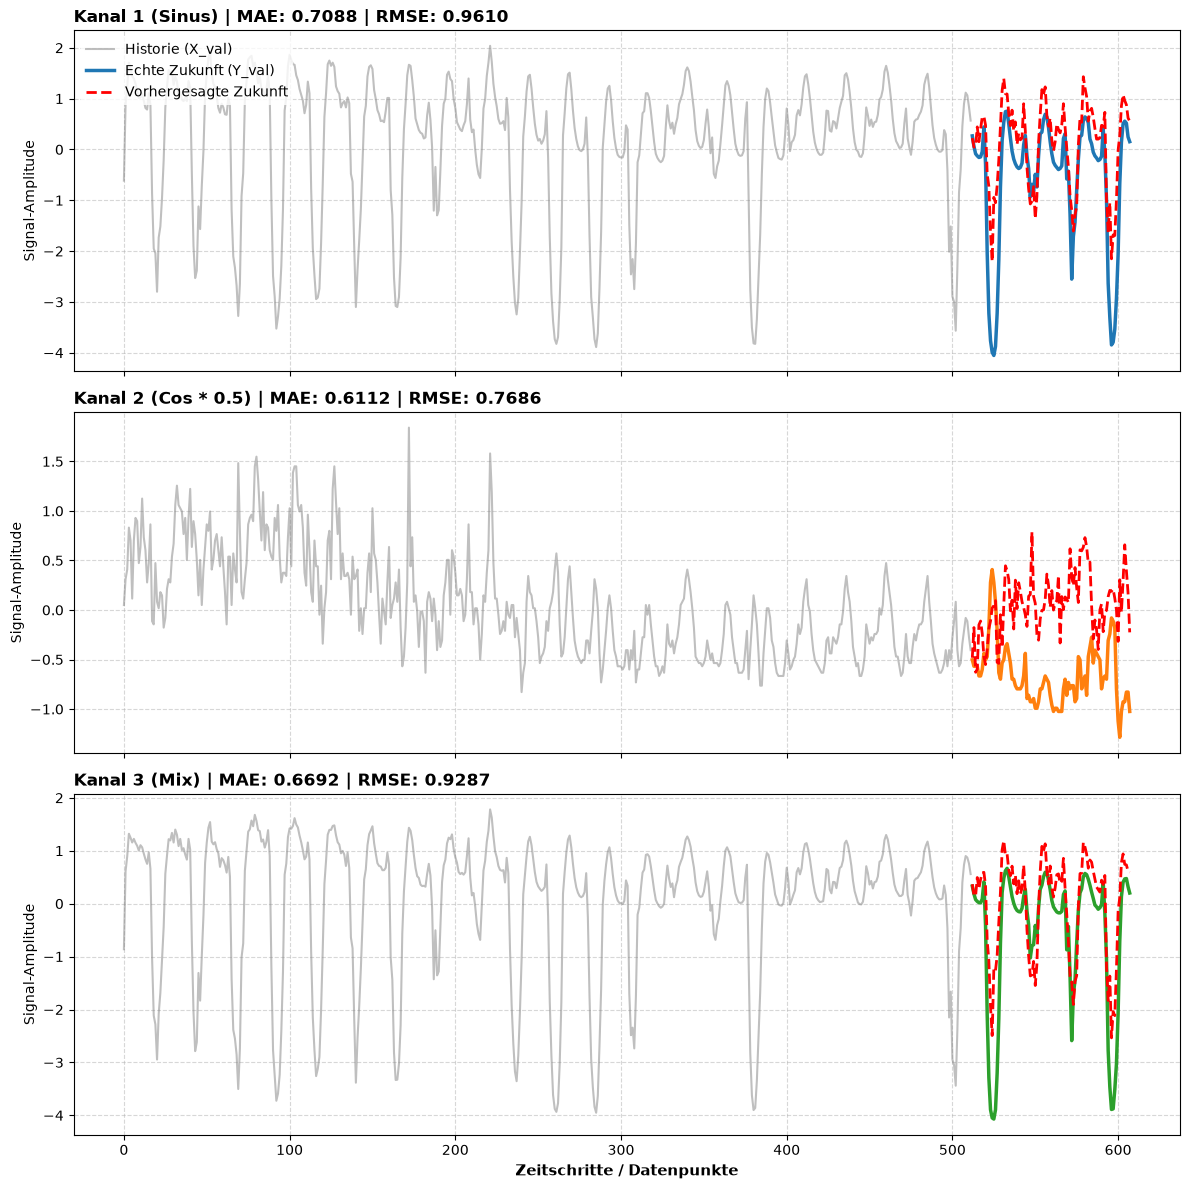

In [ ]:
#Vorhersage visualisieren

import matplotlib.pyplot as plt
import numpy as np
import warnings

def plot_forecasting_results_with_metrics(X_val, Y_val, predictions, sample_idx=0):
    """
    Plottet Historie, echte Zukunft und Vorhersage für alle 3 Kanäle.
    Berechnet und zeigt RMSE & MAE pro Kanal an.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        seq_len = X_val.shape[1]
        pred_len = Y_val.shape[1]
        
        # Zeitachsen für die Visualisierung aufbauen
        time_history = np.arange(0, seq_len)
        time_future = np.arange(seq_len, seq_len + pred_len)
        
        fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
        channel_names = ["Kanal 1 (Sinus)", "Kanal 2 (Cos * 0.5)", "Kanal 3 (Mix)"]
        colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
        
        # Schleife über alle 3 Kanäle
        for ch in range(3):
            ax = axes[ch]
            
            # Reale Werte und Vorhersagen für den aktuellen Kanal extrahieren (über den gesamten Val-Satz für stabile Metriken)
            y_true_all = Y_val[:, :, ch]
            y_pred_all = predictions[:, :, ch]
            
            # Metriken berechnen (MAE und RMSE für diesen Kanal über alle Samples)
            mae = np.mean(np.abs(y_true_all - y_pred_all))
            rmse = np.sqrt(np.mean((y_true_all - y_pred_all) ** 2))
            
            # --- 1. HISTORIE PLOTTEN (X_val) ---
            ax.plot(time_history, X_val[sample_idx, :, ch], 
                    label="Historie (X_val)", color="gray", alpha=0.5)
            
            # --- 2. ECHTE ZUKUNFT PLOTTEN (Y_val) ---
            ax.plot(time_future, Y_val[sample_idx, :, ch], 
                    label="Echte Zukunft (Y_val)", color=colors[ch], linewidth=2.5)
            
            # --- 3. VORHERSAGE PLOTTEN ---
            ax.plot(time_future, predictions[sample_idx, :, ch], 
                    label="Vorhergesagte Zukunft", color="red", linestyle="--", linewidth=2)
            
            # --- DESIGN & LABELS (Hier wurde der Fehler behoben) ---
            ax.set_ylabel("Signal-Amplitude", fontsize=10)
            ax.grid(True, linestyle="--", alpha=0.5)
            
            # Titel mit dynamischen Metriken versehen
            ax.set_title(f"{channel_names[ch]} | MAE: {mae:.4f} | RMSE: {rmse:.4f}", 
                         fontsize=12, fontweight="bold", loc="left")
            
            if ch == 0:
                ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")
                
        axes[-1].set_xlabel("Zeitschritte / Datenpunkte", fontsize=11, fontweight="bold")
        plt.tight_layout()
        plt.show()

# --- PLOT AUSFÜHREN ---
# Nutze die Methode mit deinen bestehenden Arrays
plot_forecasting_results_with_metrics(X_val, Y_val, predictions_forecast, sample_idx=0)